<a href="https://colab.research.google.com/github/Mil-333/optimization-methods/blob/main/Golden-Section/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Քայլ  | a        | b        | b-a      | x1       | x2      
-----------------------------------------------------------------
1     | 0.0000   | 3.0000   | 3.0000   | 1.146    | 1.854   
2     | 0.0000   | 1.8540   | 1.8540   | 0.708    | 1.146   
3     | 0.7082   | 1.8540   | 1.1458   | 1.146    | 1.416   
4     | 0.7082   | 1.4163   | 0.7081   | 0.979    | 1.146   
5     | 0.9787   | 1.4163   | 0.4376   | -        | -       


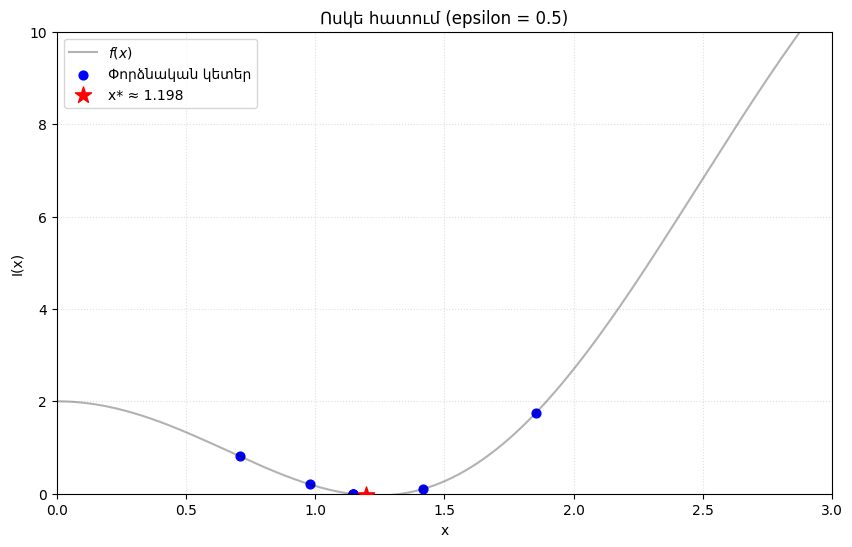

-----------------------------------------------------------------
Արդյունք 8-րդ քայլում: x* ≈ 1.1975, I(x*) ≈ -0.0340


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ֆունկցիայի սահմանում (I(x) = x^2 + 2cos)
def i_func(x):
   return x**2 + 2 * np.cos(2 * x)

# 2. Տվյալների սահմանում
a, b = 0 , 3
epsilon = 0.5
t = 0.618  # Ոսկե հատման հաստատունը[cite: 1]

history_points_x = []
history_points_y = []

curr_a, curr_b = a, b

# Սկզբնական x1 և x2 կետերի հաշվարկ[cite: 1]
x1 = curr_b - t * (curr_b - curr_a)
x2 = curr_a + t * (curr_b - curr_a)
f1, f2 = i_func(x1), i_func(x2)

print(f"{'Քայլ':<5} | {'a':<8} | {'b':<8} | {'b-a':<8} | {'x1':<8} | {'x2':<8}")
print("-" * 65)

# 3. Մինիմումի որոնում (Ցիկլը կատարվում է մինչև b-a < epsilon)[cite: 1]
step = 0
while (curr_b - curr_a) >= epsilon:
    step += 1
    # Պահում ենք կետերը գրաֆիկի համար
    history_points_x.extend([x1, x2])
    history_points_y.extend([f1, f2])

    print(f"{step:<5} | {curr_a:<8.4f} | {curr_b:<8.4f} | {curr_b - curr_a:<8.4f} | {x1:<8.3f} | {x2:<8.3f}")

    if f1 <= f2:
        curr_b = x2
        x2 = x1
        f2 = f1
        x1 = curr_b - t * (curr_b - curr_a)
        f1 = i_func(x1)
    else:
        curr_a = x1
        x1 = x2
        f1 = f2
        x2 = curr_a + t * (curr_b - curr_a)
        f2 = i_func(x2)

# 4. Վերջնական (8-րդ) քայլը՝ ըստ ձեր նկարի տրամաբանության[cite: 1]
step += 1
print(f"{step:<5} | {curr_a:<8.4f} | {curr_b:<8.4f} | {curr_b - curr_a:<8.4f} | {'-':<8} | {'-':<8}")

x_star = (curr_a + curr_b) / 2

# 5. Գրաֆիկական պատկերում (Մասշտաբի փոփոխությամբ)
x_plot = np.linspace(-6, 6, 1000)
y_plot = i_func(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, color='black', alpha=0.3, label='$f(x)$')

# Փորձնական կետերը կորի վրա
plt.scatter(history_points_x, history_points_y, color='blue', s=40, label='Փորձնական կետեր')

# Վերջնական մինիմումի կետը
plt.scatter(x_star, i_func(x_star), color='red', s=150, marker='*', label=f'x* ≈ {x_star:.3f}', zorder=10)

# --- ՄԱՍՇՏԱԲԻ ԿԱՐԳԱՎՈՐՈՒՄ ---
plt.axis([0, 3, 0, 10]) # x: [0, 3], y: [0, 10]
# -----------------------------

plt.title(f'Ոսկե հատում (epsilon = {epsilon})')
plt.xlabel('x')
plt.ylabel('I(x)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

print("-" * 65)
print(f"Արդյունք 8-րդ քայլում: x* ≈ {x_star:.4f}, I(x*) ≈ {i_func(x_star):.4f}")